In [104]:
import pandas as pd
import numpy as np

In [107]:
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding='latin1')
df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [108]:
print("Years in dataset:", df['year'].unique())

Years in dataset: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


In [109]:
df_2022 = df[df['year'] == 2022].copy()
df_2022.to_csv("hdi_2022_df.csv", index=False)
print("2022 dataset shape:", df_2022.shape)

2022 dataset shape: (206, 30)


In [110]:
df_2022.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [111]:
print("Rows:", df_2022.shape[0])
print("Columns:", df_2022.shape[1])

Rows: 206
Columns: 30


In [112]:
df_2022.dtypes

,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


In [113]:
df_2022.isnull().sum()

,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,2
life_expectancy,0
pop_millions,0
hdi_f,13
hdi_m,13
life_expec_f,0


In [116]:
for col in ['hdi','gross_inc_percap','life_expectancy']:
    df_2022[col] = pd.to_numeric(df_2022[col], errors='coerce')

In [117]:
df_2022 = df_2022.drop_duplicates()

In [118]:
df_2022 = df_2022.dropna(subset=['country','hdi'])
print("Cleaned dataset shape:", df_2022.shape)

Cleaned dataset shape: (204, 30)


In [119]:
print("HDI Mean:", round(df_2022['hdi'].mean(),3))
print("HDI Median:", round(df_2022['hdi'].median(),3))
print("HDI Std Dev:", round(df_2022['hdi'].std(),3))

HDI Mean: 0.723
HDI Median: 0.74
HDI Std Dev: 0.153


In [120]:
print("Highest HDI country:", df_2022.loc[df_2022['hdi'].idxmax(),'country'])
print("Lowest HDI country:", df_2022.loc[df_2022['hdi'].idxmin(),'country'])

Highest HDI country: Switzerland
Lowest HDI country: Somalia


In [121]:
high_hdi = df_2022[df_2022['hdi'] > 0.800]

In [124]:
sorted_high_hdi = high_hdi.sort_values(by='gross_inc_percap', ascending=False)
sorted_high_hdi[['country','hdi','gross_inc_percap']].head(10)

,country,hdi,gross_inc_percap
3332,Liechtenstein,0.942,146673.24150
4718,Qatar,0.875,95944.37754
5213,Singapore,0.949,88761.14559
2705,Ireland,0.950,87467.51391
3398,Luxembourg,0.927,78554.23640
6104,United Arab Emirates,0.937,74103.71494
5609,Switzerland,0.967,69432.78669
4322,Norway,0.966,69189.76165
6170,United States,0.927,65564.93798
2474,"Hong Kong, China (SAR)",0.956,62485.50516


In [125]:
def hdi_category(val):
    if val < 0.550:
        return "Low"
    elif val < 0.700:
        return "Medium"
    elif val < 0.800:
        return "High"
    else:
        return "Very High"

df_2022['HDI_Category'] = df_2022['hdi'].apply(hdi_category)

In [126]:
df_2022[['country','hdi','HDI_Category']].head(15)

,country,hdi,HDI_Category
32,Afghanistan,0.462,Low
65,Albania,0.789,High
98,Algeria,0.745,High
131,Andorra,0.884,Very High
164,Angola,0.591,Medium
197,Antigua and Barbuda,0.826,Very High
230,Argentina,0.849,Very High
263,Armenia,0.786,High
296,Australia,0.946,Very High
329,Austria,0.926,Very High


In [127]:
df_2022.to_csv("HDI_category_added.csv", index=False)

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [131]:
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding='latin1')

In [132]:
df_3y = df[df['year'].isin([2020, 2021, 2022])].copy()
df_3y.to_csv("HDI_problem1B.csv", index=False)
print("Filtered dataset shape:", df_3y.shape)

Filtered dataset shape: (618, 30)


In [135]:
df_3y = df_3y.drop_duplicates()
for col in ['hdi','gross_inc_percap','life_expectancy']:
    df_3y[col] = pd.to_numeric(df_3y[col], errors='coerce')
df_3y = df_3y.dropna(subset=['country','year','hdi'])

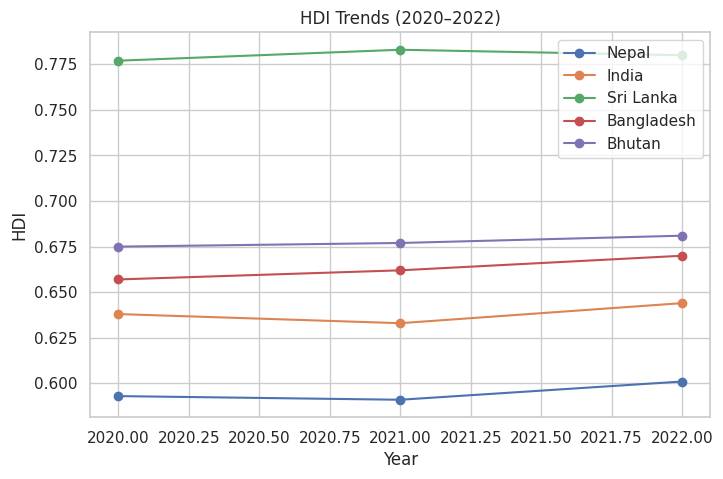

In [136]:
countries = ["Nepal","India","Sri Lanka","Bangladesh","Bhutan"]

plt.figure(figsize=(8,5))
for c in countries:
    subset = df_3y[df_3y['country'] == c]
    plt.plot(subset['year'], subset['hdi'], marker='o', label=c)

plt.title("HDI Trends (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.legend()
plt.show()

In [137]:
# Group by region and year
if 'region' in hdi_3years.columns:
    region_avg = hdi_3years.groupby(['region','year'])['hdi'].mean().reset_index()

    plt.figure(figsize=(10,6))
    sns.barplot(data=region_avg, x='region', y='hdi', hue='year')
    plt.title("Average HDI by Region (2020–2022)")
    plt.xlabel("Region")
    plt.ylabel("Average HDI")
    plt.xticks(rotation=20)
    plt.show()
else:
    print("Region column not found in dataset.")

Region column not found in dataset.


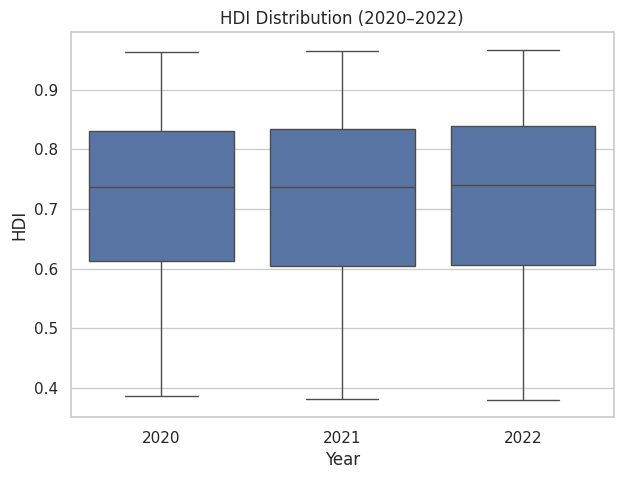

In [138]:
# Box plot for HDI distribution
plt.figure(figsize=(7,5))
sns.boxplot(data=hdi_3years, x='year', y='hdi')
plt.title("HDI Distribution (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.show()

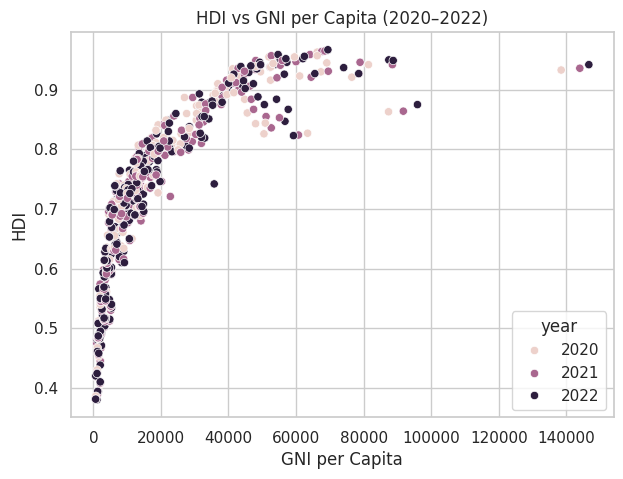

In [139]:
# Scatter plot HDI vs GNI per capita
if 'gross_inc_percap' in hdi_3years.columns:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=hdi_3years, x='gross_inc_percap', y='hdi', hue='year')
    plt.title("HDI vs GNI per Capita (2020–2022)")
    plt.xlabel("GNI per Capita")
    plt.ylabel("HDI")
    plt.show()
else:
    print("GNI per Capita variable not available in dataset.")

In [140]:
# Compute HDI change from 2020 to 2022
pivot = hdi_3years.pivot_table(index='country', columns='year', values='hdi')
pivot['change'] = pivot[2022] - pivot[2020]

# Sort by improvement
pivot.sort_values('change', ascending=False).head(10)

year,2020,2021,2022,change
country,,,,
Andorra,0.843,0.855,0.884,0.041
Azerbaijan,0.722,0.738,0.760,0.038
Ecuador,0.734,0.746,0.765,0.031
Maldives,0.737,0.753,0.762,0.025
Mexico,0.757,0.757,0.781,0.024
San Marino,0.844,0.853,0.867,0.023
Tajikistan,0.656,0.677,0.679,0.023
Bahamas,0.798,0.799,0.820,0.022
Kuwait,0.826,0.836,0.847,0.021


In [141]:
# Countries with decline in HDI
decline = pivot[pivot['change'] < 0]
decline

year,2020,2021,2022,change
country,,,,
Afghanistan,0.488,0.473,0.462,-0.026
Angola,0.594,0.590,0.591,-0.003
Australia,0.948,0.949,0.946,-0.002
Belize,0.705,0.698,0.700,-0.005
Brunei Darussalam,0.827,0.824,0.823,-0.004
Bulgaria,0.802,0.796,0.799,-0.003
Burkina Faso,0.446,0.445,0.438,-0.008
Central African Republic,0.389,0.387,0.387,-0.002
Chad,0.396,0.393,0.394,-0.002


In [142]:
# Region averages
if 'region' in hdi_3years.columns:
    region_avg_all = hdi_3years.groupby('region')['hdi'].mean().reset_index()
    print("Highest region:", region_avg_all.loc[region_avg_all['hdi'].idxmax()])
    print("Lowest region:", region_avg_all.loc[region_avg_all['hdi'].idxmin()])
else:
    print("Region column not found in dataset.")

Region column not found in dataset.


In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [150]:
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding='latin1')


In [147]:
south_asia = ["Afghanistan","Bangladesh","Bhutan","India",
              "Maldives","Nepal","Pakistan","Sri Lanka"]

sa_df = df[df['country'].isin(south_asia)].copy()
sa_df.to_csv("HDI_SouthAsia.csv", index=False)
print("South Asia dataset shape:", sa_df.shape)

South Asia dataset shape: (264, 30)


In [153]:
# Normalize life expectancy and GNI per capita for comparability
sa_df['life_expec_norm'] = sa_df.groupby('year')['life_expectancy'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
sa_df['gross_inc_norm'] = sa_df.groupby('year')['gross_inc_percap'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# Composite Score formula
sa_df['Composite_Score'] = 0.30*sa_df['life_expec_norm'] + 0.30*sa_df['gross_inc_norm']

# Rank countries by average Composite Score (2020–2022)
rank_df = sa_df[sa_df['year'].isin([2020,2021,2022])].groupby('country')['Composite_Score'].mean().reset_index()
rank_df = rank_df.sort_values('Composite_Score', ascending=False)

rank_df

,country,Composite_Score
4,Maldives,0.597564
7,Sri Lanka,0.471591
2,Bhutan,0.343570
1,Bangladesh,0.268831
3,India,0.203635
5,Nepal,0.164752
6,Pakistan,0.138429
0,Afghanistan,0.000000


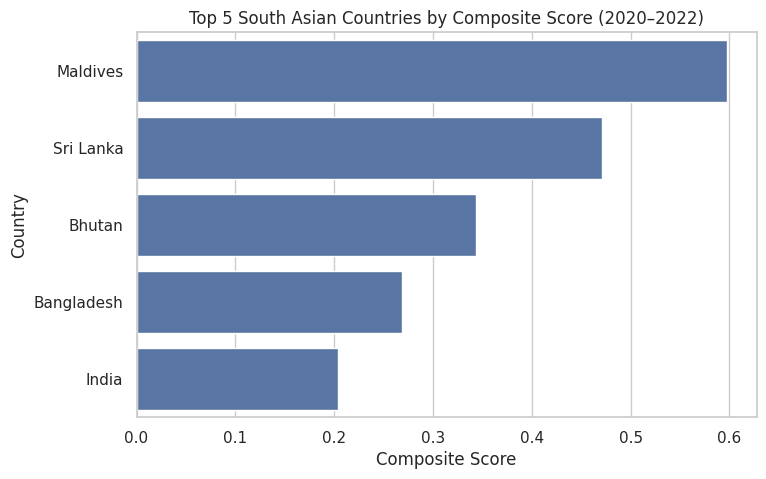

In [154]:
top5 = rank_df.head(5)

plt.figure(figsize=(8,5))
sns.barplot(data=top5, x='Composite_Score', y='country', orient='h')
plt.title("Top 5 South Asian Countries by Composite Score (2020–2022)")
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.show()

In [155]:
hdi_rank = sa_df[sa_df['year'].isin([2020,2021,2022])].groupby('country')['hdi'].mean().reset_index()
hdi_rank = hdi_rank.sort_values('hdi', ascending=False)

print("Composite Score Ranking:\n", rank_df)
print("\nHDI Ranking:\n", hdi_rank)

Composite Score Ranking:
        country  Composite_Score
4     Maldives         0.597564
7    Sri Lanka         0.471591
2       Bhutan         0.343570
1   Bangladesh         0.268831
3        India         0.203635
5        Nepal         0.164752
6     Pakistan         0.138429
0  Afghanistan         0.000000

HDI Ranking:
        country       hdi
7    Sri Lanka  0.780000
4     Maldives  0.750667
2       Bhutan  0.677667
1   Bangladesh  0.663000
3        India  0.638333
5        Nepal  0.595000
6     Pakistan  0.537667
0  Afghanistan  0.474333


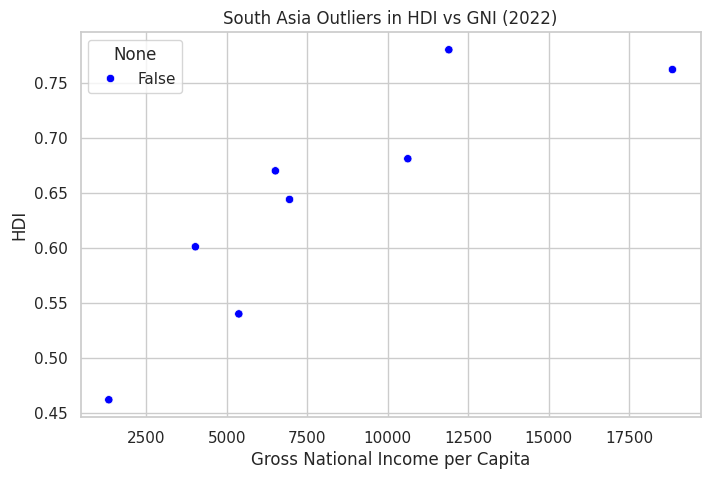

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,life_expec_norm,gross_inc_norm,Composite_Score,hdi_outlier,gni_outlier


In [158]:
sa_2022 = sa_df[sa_df['year'] == 2022].copy()

def detect_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lower) | (series > upper)

sa_2022['hdi_outlier'] = detect_outliers(sa_2022['hdi'])
sa_2022['gni_outlier'] = detect_outliers(sa_2022['gross_inc_percap'])

plt.figure(figsize=(8,5))
sns.scatterplot(data=sa_2022, x='gross_inc_percap', y='hdi',
                hue=sa_2022['hdi_outlier'] | sa_2022['gni_outlier'],
                palette={True:'red', False:'blue'})
plt.title("South Asia Outliers in HDI vs GNI (2022)")
plt.xlabel("Gross National Income per Capita")
plt.ylabel("HDI")
plt.show()

sa_2022[sa_2022['hdi_outlier'] | sa_2022['gni_outlier']]

Correlation between gender_development and HDI: 0.874


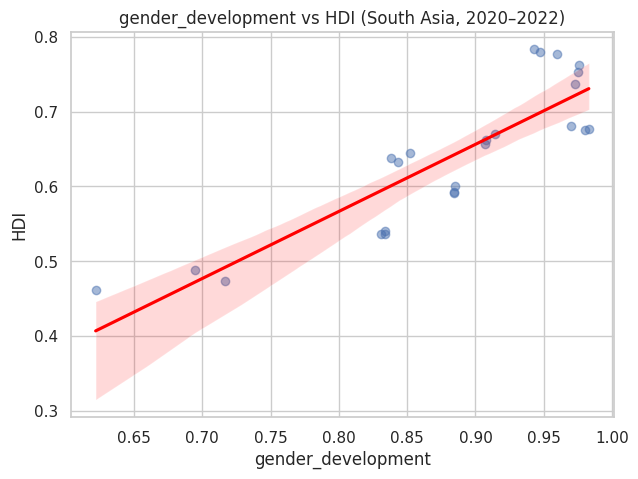

Correlation between life_expectancy and HDI: 0.939


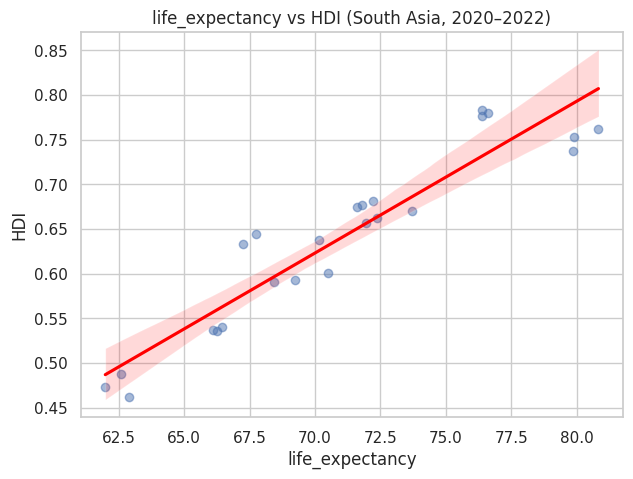

In [160]:
sa_recent = sa_df[sa_df['year'].isin([2020,2021,2022])]

for metric in ['gender_development','life_expectancy']:
    corr = sa_recent[[metric,'hdi']].corr().iloc[0,1]
    print(f"Correlation between {metric} and HDI:", round(corr,3))

    plt.figure(figsize=(7,5))
    sns.regplot(data=sa_recent, x=metric, y='hdi', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f"{metric} vs HDI (South Asia, 2020–2022)")
    plt.xlabel(metric)
    plt.ylabel("HDI")
    plt.show()

/tmp/ipython-input-2367892361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sa_recent['GNI_HDI_Gap'] = sa_recent['gross_inc_percap'] - sa_recent['hdi']


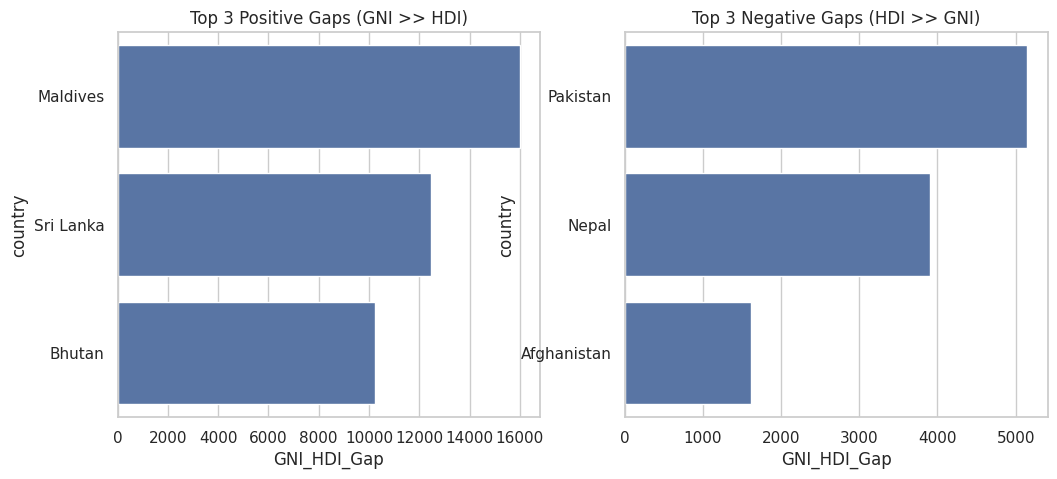

,country,GNI_HDI_Gap
4,Maldives,16011.230657
7,Sri Lanka,12481.929060
2,Bhutan,10253.395723
3,India,6526.906040
1,Bangladesh,6184.158880
6,Pakistan,5149.963106
5,Nepal,3901.138692
0,Afghanistan,1618.240627


In [163]:
sa_recent['GNI_HDI_Gap'] = sa_recent['gross_inc_percap'] - sa_recent['hdi']

gap_avg = sa_recent.groupby('country')['GNI_HDI_Gap'].mean().reset_index()
gap_avg = gap_avg.sort_values('GNI_HDI_Gap', ascending=False)

top3_pos = gap_avg.head(3)
top3_neg = gap_avg.tail(3)

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(data=top3_pos, x='GNI_HDI_Gap', y='country', ax=axes[0], orient='h')
axes[0].set_title("Top 3 Positive Gaps (GNI >> HDI)")

sns.barplot(data=top3_neg, x='GNI_HDI_Gap', y='country', ax=axes[1], orient='h')
axes[1].set_title("Top 3 Negative Gaps (HDI >> GNI)")

plt.show()

gap_avg

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [165]:
# Load the dataset you saved in Problem 1B
df_3y = pd.read_csv("HDI_problem1B.csv")
print("Shape:", df_3y.shape)
df_3y.head()

Shape: (618, 30)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
1,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
2,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
3,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
4,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


In [166]:
south_asia = ["Afghanistan","Bangladesh","Bhutan","India",
              "Maldives","Nepal","Pakistan","Sri Lanka"]

middle_east = ["Bahrain","Iran","Iraq","Israel","Jordan",
               "Kuwait","Lebanon","Oman","Palestine","Qatar",
               "Saudi Arabia","Syria","United Arab Emirates","Yemen"]

sa_3y = df_3y[df_3y['country'].isin(south_asia)].copy()
me_3y = df_3y[df_3y['country'].isin(middle_east)].copy()

sa_3y.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
me_3y.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

print("South Asia shape:", sa_3y.shape)
print("Middle East shape:", me_3y.shape)

South Asia shape: (24, 30)
Middle East shape: (33, 30)


In [167]:
def region_stats(df, name):
    return {"Region": name,
            "HDI_mean": df['hdi'].mean(),
            "HDI_std": df['hdi'].std()}

stats = pd.DataFrame([
    region_stats(sa_3y, "South Asia"),
    region_stats(me_3y, "Middle East")
])

stats

,Region,HDI_mean,HDI_std
0,South Asia,0.639583,0.098273
1,Middle East,0.788909,0.141295


In [168]:
sa_rank = sa_3y.groupby('country')['hdi'].mean().reset_index().sort_values('hdi', ascending=False)
me_rank = me_3y.groupby('country')['hdi'].mean().reset_index().sort_values('hdi', ascending=False)

sa_top3, sa_bottom3 = sa_rank.head(3), sa_rank.tail(3)
me_top3, me_bottom3 = me_rank.head(3), me_rank.tail(3)

print("South Asia Top 3:\n", sa_top3)
print("\nSouth Asia Bottom 3:\n", sa_bottom3)
print("\nMiddle East Top 3:\n", me_top3)
print("\nMiddle East Bottom 3:\n", me_bottom3)

South Asia Top 3:
      country       hdi
7  Sri Lanka  0.780000
4   Maldives  0.750667
2     Bhutan  0.677667

South Asia Bottom 3:
        country       hdi
5        Nepal  0.595000
6     Pakistan  0.537667
0  Afghanistan  0.474333

Middle East Top 3:
                 country       hdi
9  United Arab Emirates  0.932667
2                Israel  0.910667
0               Bahrain  0.885333

Middle East Bottom 3:
     country       hdi
5   Lebanon  0.730000
1      Iraq  0.667000
10    Yemen  0.426333


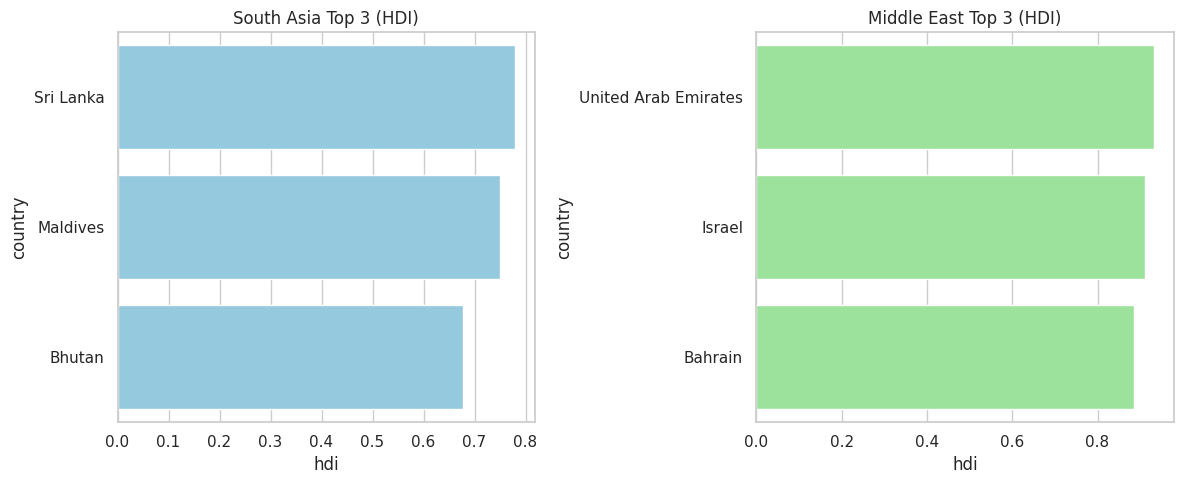

In [180]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=sa_top3, x='hdi', y='country', ax=axes[0], color='skyblue')
axes[0].set_title("South Asia Top 3 (HDI)")

sns.barplot(data=me_top3, x='hdi', y='country', ax=axes[1], color='lightgreen')
axes[1].set_title("Middle East Top 3 (HDI)")

plt.tight_layout()
plt.show()

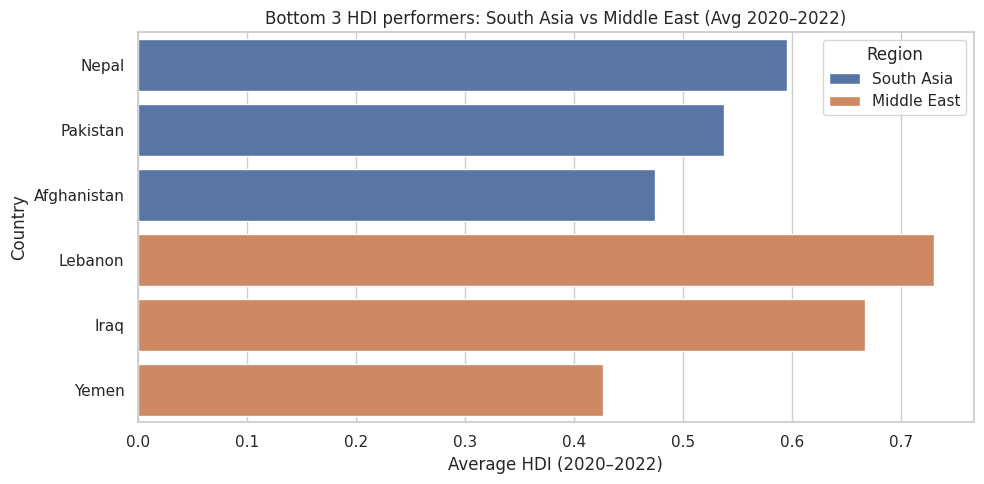

In [181]:
# Prepare data with region labels for a single combined plot
sa_b = sa_bottom3.assign(Region="South Asia")
me_b = me_bottom3.assign(Region="Middle East")
bottom_combined = pd.concat([sa_b, me_b], ignore_index=True)

plt.figure(figsize=(10,5))
sns.barplot(data=bottom_combined, x='hdi', y='country', hue='Region', orient='h')
plt.title("Bottom 3 HDI performers: South Asia vs Middle East (Avg 2020–2022)")
plt.xlabel("Average HDI (2020–2022)")
plt.ylabel("Country")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

In [172]:
metrics = ['gender_development','life_expectancy','gross_inc_percap']

sa_metrics = sa_3y[metrics].mean().rename("South Asia")
me_metrics = me_3y[metrics].mean().rename("Middle East")

comp = pd.concat([sa_metrics, me_metrics], axis=1)
comp

,South Asia,Middle East
gender_development,0.881458,0.896545
life_expectancy,70.970083,75.855455
gross_inc_percap,7766.509931,37750.770520


In [173]:
def disparity(df):
    rng = df['hdi'].max() - df['hdi'].min()
    cv = df['hdi'].std() / df['hdi'].mean()
    return rng, cv

sa_range, sa_cv = disparity(sa_3y)
me_range, me_cv = disparity(me_3y)

print("South Asia - Range:", sa_range, "CV:", sa_cv)
print("Middle East - Range:", me_range, "CV:", me_cv)

South Asia - Range: 0.321 CV: 0.1536520924690084
Middle East - Range: 0.5130000000000001 CV: 0.17910145193048382


South Asia correlation (gender_development vs HDI): 0.874


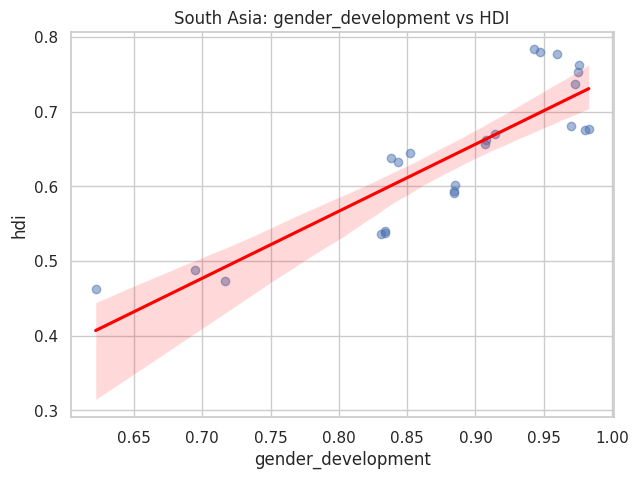

South Asia correlation (life_expectancy vs HDI): 0.939


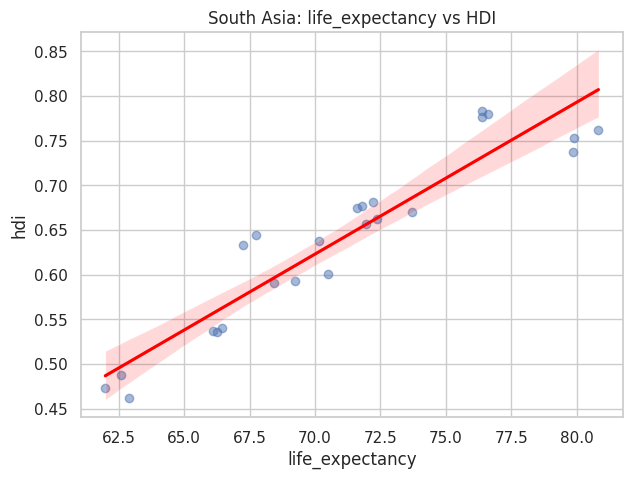

Middle East correlation (gender_development vs HDI): 0.936


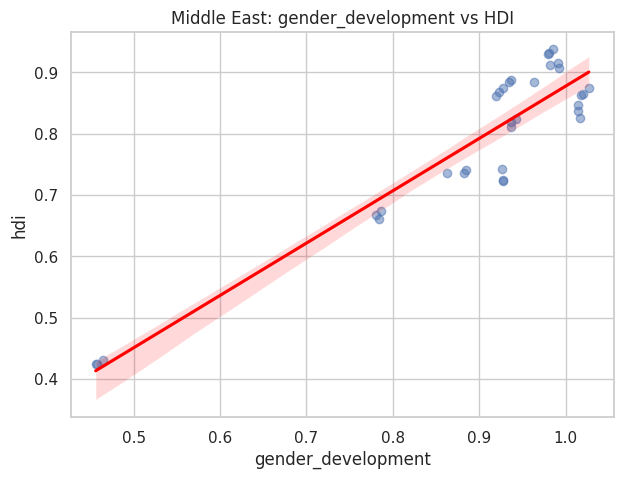

Middle East correlation (life_expectancy vs HDI): 0.933


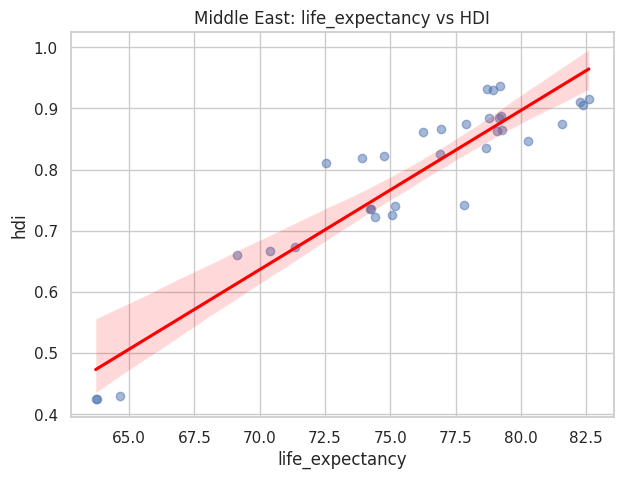

In [176]:
for region, df in [("South Asia", sa_3y), ("Middle East", me_3y)]:
    for metric in ['gender_development','life_expectancy']:
        corr = df[[metric,'hdi']].corr().iloc[0,1]
        print(f"{region} correlation ({metric} vs HDI):", round(corr,3))

        plt.figure(figsize=(7,5))
        sns.regplot(data=df, x=metric, y='hdi', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        plt.title(f"{region}: {metric} vs HDI")
        plt.show()

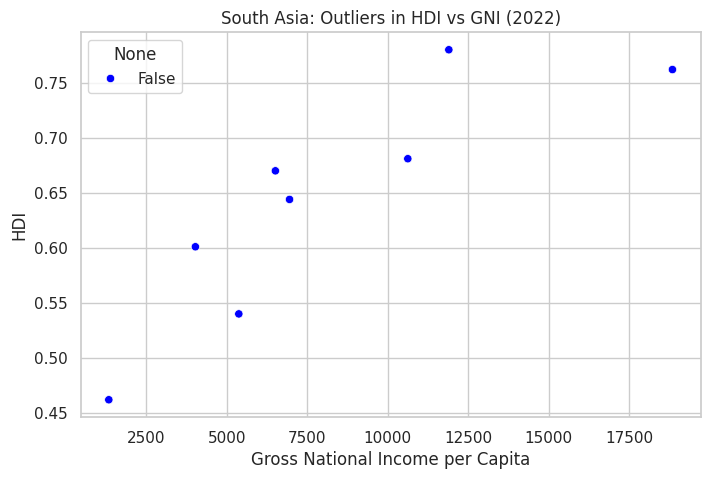

South Asia outliers:
 Empty DataFrame
Columns: [country, hdi, gross_inc_percap]
Index: []


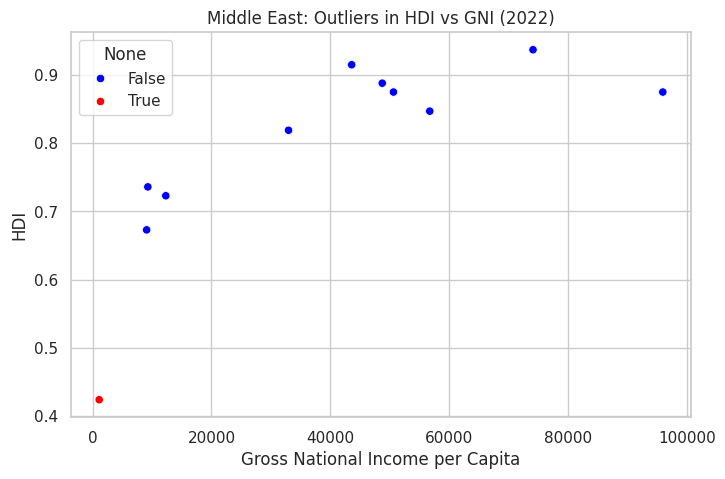

Middle East outliers:
     country    hdi  gross_inc_percap
578   Yemen  0.424       1105.763435


In [179]:
def detect_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lower) | (series > upper)

for region, df in [("South Asia", sa_3y), ("Middle East", me_3y)]:
    d2022 = df[df['year']==2022].copy()
    d2022['hdi_out'] = detect_outliers(d2022['hdi'])
    d2022['gni_out'] = detect_outliers(d2022['gross_inc_percap'])

    plt.figure(figsize=(8,5))
    sns.scatterplot(data=d2022, x='gross_inc_percap', y='hdi',
                    hue=d2022['hdi_out'] | d2022['gni_out'],
                    palette={True:'red', False:'blue'})
    plt.title(f"{region}: Outliers in HDI vs GNI (2022)")
    plt.xlabel("Gross National Income per Capita")
    plt.ylabel("HDI")
    plt.show()

    print(f"{region} outliers:\n", d2022[d2022['hdi_out'] | d2022['gni_out']][['country','hdi','gross_inc_percap']])